<a href="https://colab.research.google.com/github/shiomiayari/Kyouyouhakusyo/blob/main/COMPAS_MLP_lecture_1_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# pandasとtensorflowのインストール（必要に応じて）
!pip install pandas tensorflow scikit-learn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import random as random
import os
import sys
import copy

In [ ]:
#乱数の固定化

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    if "torch" in sys.modules:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

In [ ]:
# Compasデータセットのダウンロード
!wget https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv

# pandasでデータを読み込む
data = pd.read_csv("compas-scores-two-years.csv")

# データの最初の5行を表示して確認
print(data.head())


--2025-04-16 02:20:20--  https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546489 (2.4M) [text/plain]
Saving to: ‘compas-scores-two-years.csv’

compas-scores-two-y 100%[===================>]   2.43M  --.-KB/s    in 0.05s   

2025-04-16 02:20:21 (48.3 MB/s) - ‘compas-scores-two-years.csv’ saved [2546489/2546489]

   id                name   first         last compas_screening_date   sex  \
0   1    miguel hernandez  miguel    hernandez            2013-08-14  Male   
1   3         kevon dixon   kevon        dixon            2013-01-27  Male   
2   4            ed philo      ed        philo            2013-04-14  Male   
3   5         marcu brown   marcu        brown 

In [ ]:
# データ（特徴量）をPandasのデータフレームに変換
df_data = data
# ターゲット（ラベル）を別に保存
target = data['two_year_recid']

#NaNを含むColumn名
nan_columns = df_data.columns[df_data.isnull().any()].tolist()
print("NaNを含む列:", nan_columns)


#欠損値がある行を削除
df_data = data.dropna()
# 不要な列を削除（例：idなど）
df_data = data.drop(columns=['id', 'first','last','start','end','event'], axis=1)
df_data = df_data.drop(nan_columns, axis=1)


df_encoded = pd.get_dummies(df_data)

# ターゲット（ラベル）をOne-Hot Encoding後のデータフレームに追加
df_encoded['target'] = target

X = df_encoded.drop(['two_year_recid','is_recid','is_violent_recid','target'], axis=1)  # 特徴量

y = df_encoded['target'] if 'target' in df_encoded.columns else df_data['target']  # 'target'が存在する場合のみ取得



NaNを含む列: ['days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_desc', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'in_custody', 'out_custody']


**レポート時はここより上記は変更しないこと．**

In [ ]:
# 訓練セットとテストセットに分割
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state=42)

# データの標準化

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# NumPy配列からPyTorchのテンソルに変換
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)  # 二値分類の場合、ラベルはlong型

In [ ]:
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
class CompasDataset:
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [ ]:
batch_size = 128
train_dataset = CompasDataset(X_train_tensor, y_train_tensor)
val_dataset = CompasDataset(X_val_tensor, y_val_tensor)
test_dataset = CompasDataset(X_test_tensor, y_test_tensor)
# データローダーの作成
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(train_dataset)

In [ ]:
class CompasDataset:
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels  # Assign labels directly instead of calling .values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx] # Access elements using indexing

In [ ]:
length=len(X.columns)
print(length)

14710


In [ ]:
# 訓練に際して、可能であればGPU（cuda）を設定します。GPUが搭載されていない場合はCPUを使用します
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

# modelを定義します
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(14710,4096),
            nn.ReLU(),
            nn.Linear(4096, 1028),
            nn.ReLU(),
            nn.Linear(1028, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32,2)
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        a=nn.Softmax(dim=1)
        b=a(logits)
        return b


model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=14710, out_features=4096, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4096, out_features=1028, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1028, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
for name, param in model.named_parameters():
    print(f"{name}: mean={param.data.mean().item()}, std={param.data.std().item()}")

linear_relu_stack.0.weight: mean=1.2445524077975278e-07, std=0.004760155454277992
linear_relu_stack.0.bias: mean=-0.00011502498091431335, std=0.004702773876488209
linear_relu_stack.2.weight: mean=3.1850561299506808e-06, std=0.009021349251270294
linear_relu_stack.2.bias: mean=0.0004295764665585011, std=0.008915606886148453
linear_relu_stack.4.weight: mean=4.385258307593176e-06, std=0.01795370876789093
linear_relu_stack.4.bias: mean=-0.0011230830568820238, std=0.017231091856956482
linear_relu_stack.6.weight: mean=0.0014277853770181537, std=0.0510542057454586
linear_relu_stack.6.bias: mean=0.013480653055012226, std=0.054237499833106995
linear_relu_stack.8.weight: mean=0.007802755106240511, std=0.09533087909221649
linear_relu_stack.8.bias: mean=-0.07766301929950714, std=0.010624540969729424


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # 損失誤差を計算
        pred = model(X)
        #print(pred)
        loss = loss_fn(pred, y)

        # バックプロパゲーション
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 10 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def test(dataloader, model):
    size = len(dataloader.dataset)
    model.eval()
    avg_loss, accuracy = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            avg_loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()
    avg_loss /= size
    accuracy /= size
    return avg_loss, accuracy


In [ ]:
epochs = 100
patience = 5
best_val_loss = float("inf")
patience_counter = 0

In [ ]:

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    val_loss, val_accuracy = test(val_loader, model)
    print(f"Val Error: \n Accuracy: {(100*val_accuracy):>0.1f}%, Val loss: {val_loss:>8f} \n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
      print("Early stopping triggered!")
      break

print("Done!")

test_loss, test_accuracy = test(test_loader, model)
print(f"Test Error: \n Accuracy: {(100*test_accuracy):>0.1f}%, Val loss: {test_loss:>8f} \n")


Epoch 1
-------------------------------
loss: 0.691446  [    0/ 4328]
loss: 0.692662  [ 1280/ 4328]
loss: 0.692124  [ 2560/ 4328]
loss: 0.692348  [ 3840/ 4328]
Val Error: 
 Accuracy: 55.8%, Val loss: 0.005755 

Epoch 2
-------------------------------
loss: 0.690620  [    0/ 4328]
loss: 0.692453  [ 1280/ 4328]
loss: 0.690782  [ 2560/ 4328]
loss: 0.691409  [ 3840/ 4328]
Val Error: 
 Accuracy: 55.8%, Val loss: 0.005751 

Epoch 3
-------------------------------
loss: 0.693578  [    0/ 4328]
loss: 0.692128  [ 1280/ 4328]
loss: 0.691978  [ 2560/ 4328]
loss: 0.693824  [ 3840/ 4328]
Val Error: 
 Accuracy: 55.8%, Val loss: 0.005748 

Epoch 4
-------------------------------
loss: 0.691426  [    0/ 4328]
loss: 0.693313  [ 1280/ 4328]
loss: 0.691716  [ 2560/ 4328]
loss: 0.691211  [ 3840/ 4328]
Val Error: 
 Accuracy: 55.8%, Val loss: 0.005745 

Epoch 5
-------------------------------
loss: 0.692884  [    0/ 4328]
loss: 0.693044  [ 1280/ 4328]
loss: 0.695115  [ 2560/ 4328]
loss: 0.690457  [ 3840/ 43

In [ ]:
y_pred = model(X_test_tensor.to(device)).argmax(1)

              precision    recall  f1-score   support

           0      0.713     0.786     0.748       823
           1      0.671     0.579     0.622       620

    accuracy                          0.697      1443
   macro avg      0.692     0.683     0.685      1443
weighted avg      0.695     0.697     0.693      1443



<Axes: >

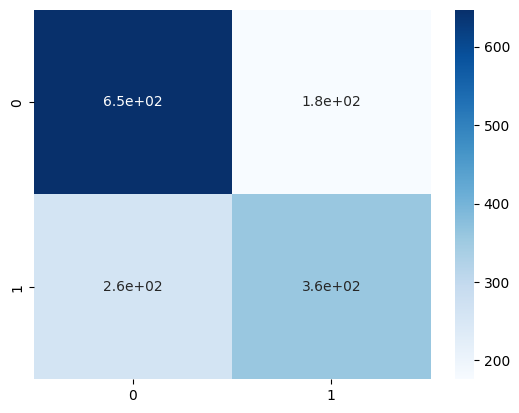

In [ ]:
# テスト用データで予測値を生成する

# テスト用データで予測した結果のclassfication_reportを表示する
from sklearn.metrics import classification_report

# classfication_reportを表示
print(classification_report(y_test_tensor.cpu(),y_pred.cpu(),digits=3))

# 混同行列を作成してseabornで表示する
from sklearn.metrics import confusion_matrix
import seaborn as sns
# 混同行列を表示
cm = confusion_matrix(y_test_tensor.cpu(),y_pred.cpu())
sns.heatmap(cm, annot=True, cmap='Blues')
